# All the parameters that need to be changed

In [2]:
# Mississippi
state_ab = "ms"

## Data
1. Download all the data in directory "ms_data"
2. Eextract them all

In [4]:
data_folder = state_ab + "_data/"
population1_data = "./{}{}_pl2020_b/{}_pl2020_p1_b.shp".format(data_folder, state_ab, state_ab)
population2_data = "./{}{}_pl2020_b/{}_pl2020_p2_b.shp".format(data_folder, state_ab, state_ab)
vap_data =  "./{}{}_pl2020_b/{}_pl2020_p4_b.shp".format(data_folder, state_ab, state_ab)
vest20_data = "./{}{}_vest_20/{}_vest_20.shp".format(data_folder, state_ab, state_ab)
vest19_data = "./{}{}_vest_19/{}_vest_19.shp".format(data_folder, state_ab, state_ab)
vest18_data = "./{}{}_vest_18/{}_vest_18.shp".format(data_folder, state_ab, state_ab)
vest16_data = "./{}{}_vest_16/{}_vest_16.shp".format(data_folder, state_ab, state_ab)
elec22_data = "./{}ms_gen_22_prec/ms_gen_22_prec.shp".format(data_folder)
cd_data = "./{}{}_cong_adopted_2022/MS_USCongDists_2022.shp".format(data_folder, state_ab)
send_data = "./{}{}_sldu_adopted_2022/MS_SenateDists_Mar2022.shp".format(data_folder, state_ab)
hdist_data = "./{}{}_sldl_adopted_2022/MS_HouseDists_Mar292022.shp".format(data_folder, state_ab)
county_data = "./{}{}_pl2020_cnty/{}_pl2020_cnty.shp".format(data_folder, state_ab, state_ab)

## Parameters that needs to be manually checked

### base vest data
start_col = 5\
vest_base_data = vest20\
year = '20'

### district data
district column name of cong_df, send, hdist when calling add_dist()

# Program starts

In [7]:
import pandas as pd
import geopandas as gpd
import maup
import time
from maup import smart_repair
from gerrychain import Graph
import os

maup.progress.enabled = True

In [8]:
import warnings
warnings.filterwarnings("ignore")

In [9]:
def do_smart_repair(df, min_rook_length = None, snap_precision = 10):
    # change it to the UTM it needs for smart_repair
    df = df.to_crs(df.estimate_utm_crs())
    df = smart_repair(df, min_rook_length = min_rook_length, snap_precision = snap_precision)

    if maup.doctor(df) == False:
        raise Exception('maup.doctor failed')
    
    return df

In [10]:
def add_district(dist_df, dist_name, election_df, col_name):
    election_df = election_df.to_crs(election_df.estimate_utm_crs())
    dist_df = dist_df.to_crs(dist_df.estimate_utm_crs())
    # check if it needs to be smart_repair
    if maup.doctor(dist_df) != True:
        dist_df = do_smart_repair(dist_df)

    # assigne the pricincts
    precincts_to_district_assignment = maup.assign(election_df.geometry, dist_df.geometry)
    election_df[dist_name] = precincts_to_district_assignment
    for precinct_index in range(len(election_df)):
        election_df.at[precinct_index, dist_name] = dist_df.at[election_df.at[precinct_index, dist_name], col_name]

    return election_df

In [11]:
def rename(original, year):
    party = original[6]
    if party == 'R' or party == 'D':
        return original[3:6] + year + original[6]
    else:
        return original[3:6] + year + 'O'

In [12]:
def check_population(population, df):
    pop_check = pd.DataFrame({
        'pop_col': pop_col,
        'population_df': population[pop_col].sum(), 
        'vest_base': df[pop_col].sum(),
        'equal': [x == y for x, y in zip(population[pop_col].sum(), df[pop_col].sum())]
    })
    if pop_check['equal'].mean() < 1:
        print(pop_check)
        raise Exception("population doesn't agree")

    else:
        print("population agrees")

In [13]:
def add_vest(vest, df, year, population, start_col, snap_precision = 10, disconnection_threshold=0.0001):
    df = df.to_crs(df.estimate_utm_crs())
    vest = vest.to_crs(vest.estimate_utm_crs())
    population = population.to_crs(population.estimate_utm_crs())
    df_crs = df.crs
    vest_crs = vest.crs

     # check if it needs to be smart_repair
    if maup.doctor(vest) != True:
        vest = do_smart_repair(vest, snap_precision = snap_precision, disconnection_threshold = disconnection_threshold)
    
    # rename the columns
    original_col = vest.columns[start_col:-1]
    new_col = [rename(i, year) for i in original_col]
    rename_dict = dict(zip(original_col, new_col))
    vest = vest.rename(columns=rename_dict)
    vest = vest.groupby(level=0, axis=1).sum() # combine all the other party's vote into columns with sufix "O"
    col_name = list(set(new_col))
    col_name.sort()
    
    # make the blocks from precincts by weight
    vest = gpd.GeoDataFrame(vest, crs=vest_crs)
    election_in_block = population[["VAP", 'geometry']] # population_df is in block scale
    blocks_to_precincts_assignment = maup.assign(election_in_block.geometry, vest.geometry)
    weights = election_in_block["VAP"] / blocks_to_precincts_assignment.map(election_in_block["VAP"].groupby(blocks_to_precincts_assignment).sum())
    weights = weights.fillna(0)
    prorated = maup.prorate(blocks_to_precincts_assignment, vest[col_name], weights)
    election_in_block[col_name] = prorated
    
    # assign blocks to precincts
    election_in_block = gpd.GeoDataFrame(election_in_block, crs=vest_crs)
    df = gpd.GeoDataFrame(df, crs=df_crs)
    block_to_pricinct_assginment = maup.assign(election_in_block.geometry, df.geometry)
    df[col_name] = election_in_block[col_name].groupby(block_to_pricinct_assginment).sum()
    df = df.groupby(level=0, axis=1).sum()
    df = gpd.GeoDataFrame(df, crs = df_crs)
    # check if population agrees
    check_population(population, df)
    
    return df

In [14]:
def add_vest_base(vest, start_col, year, county = None, min_rook_length = None, snap_precision = 10):
    vest = vest.to_crs(vest.estimate_utm_crs())
    vest_crs = vest.crs
    original_col = vest.columns[start_col:-1]
    new_col = [rename(i, year) for i in original_col]
    rename_dict = dict(zip(original_col, new_col))
    vest = vest.rename(columns=rename_dict)
    vest = vest.groupby(level=0, axis=1).sum()
    vest = gpd.GeoDataFrame(vest, crs=vest_crs)

    if county is not None:
        county = county.to_crs(county.estimate_utm_crs())
        vest = smart_repair(vest, nest_within_regions = county, min_rook_length = min_rook_length, snap_precision = snap_precision) # nest precincts within counties

    else:
        vest = smart_repair(vest, min_rook_length = min_rook_length, snap_precision = snap_precision) 
    
    return vest

In [15]:
def check_small_boundary_lengths(vest_base):
    import copy
    vest_base = vest_base.to_crs(vest_base.estimate_utm_crs())

    boundaries = copy.deepcopy(vest_base)
    boundaries["geometry"] = boundaries.geometry.boundary  # get boundaries
    neighbors = gpd.sjoin(boundaries, vest_base, predicate="intersects") # find boundaries that intersect
    neighbors = neighbors[neighbors.index != neighbors.index_right] # remove boundaries of a region with itself

    # compute shared border length using intersection
    borders = list(neighbors.apply(
        lambda row: row.geometry.intersection(vest_base.loc[row.index_right, "geometry"]).length, axis=1
    ))

    borders.sort()
    
    return borders

## Read the census data

In [17]:
population1_df = gpd.read_file(population1_data)
population2_df = gpd.read_file(population2_data)
vap_df = gpd.read_file(vap_data)
county_df = gpd.read_file(county_data)

In [18]:
population2_df = population2_df.drop(columns=['SUMLEV', 'LOGRECNO', 'GEOID', 'COUNTY', 'geometry'])
vap_df = vap_df.drop(columns=['SUMLEV', 'LOGRECNO', 'GEOID', 'COUNTY', 'geometry'])

In [19]:
population_df = pd.merge(population1_df, population2_df, on='GEOID20')
population_df = pd.merge(population_df, vap_df, on='GEOID20')
population_df = population_df.to_crs(population_df.estimate_utm_crs())

In [20]:
maup.doctor(population_df)

100%|█████████████████████████████████| 112241/112241 [00:41<00:00, 2698.79it/s]


True

In [21]:
rename_dict = {'P0020001': 'TOTPOP', 'P0020002': 'HISP', 'P0020005': 'NH_WHITE', 'P0020006': 'NH_BLACK', 'P0020007': 'NH_AMIN',
               'P0020008': 'NH_ASIAN', 'P0020009': 'NH_NHPI', 'P0020010': 'NH_OTHER', 'P0020011': 'NH_2MORE',
               'P0040001': 'VAP', 'P0040002': 'HVAP', 'P0040005': 'WVAP', 'P0040006': 'BVAP', 'P0040007': 'AMINVAP',
               'P0040008': 'ASIANVAP', 'P0040009': 'NHPIVAP', 'P0040010': 'OTHERVAP', 'P0040011': '2MOREVAP'}

In [22]:
population_df.rename(columns=rename_dict, inplace = True)

In [23]:
population_df['H_WHITE'] = population_df.apply(lambda t: t['P0010003'] - t['NH_WHITE'], 1)
population_df['H_BLACK'] = population_df.apply(lambda t: t['P0010004'] - t['NH_BLACK'], 1)
population_df['H_AMIN'] = population_df.apply(lambda t: t['P0010005'] - t['NH_AMIN'], 1)
population_df['H_ASIAN'] = population_df.apply(lambda t: t['P0010006'] - t['NH_ASIAN'], 1)
population_df['H_NHPI'] = population_df.apply(lambda t: t['P0010007'] - t['NH_NHPI'], 1)
population_df['H_OTHER'] = population_df.apply(lambda t: t['P0010008'] - t['NH_OTHER'], 1)
population_df['H_2MORE'] = population_df.apply(lambda t: t['P0010009'] - t['NH_2MORE'], 1)

Make sure that the County shapefile is clean:

In [25]:
maup.doctor(county_df)

100%|██████████████████████████████████████████| 82/82 [00:00<00:00, 408.89it/s]


True

# Read the base vest data
Now using it as a "base precinct", but it could be vest 18 or vest 16 if vest 20 is not working

### Check if vest 18 can be used as base

In [28]:
vest18 = gpd.read_file(vest18_data)

In [29]:
vest18.columns

Index(['STATEFP18', 'COUNTYFP18', 'VTDST18', 'GEOID18', 'NAME18', 'G18USSRWIC',
       'G18USSDBAR', 'G18USSLBED', 'G18USSOOHA', 'S18USSRHYD', 'S18USSRMCD',
       'S18USSDESP', 'S18USSDBAR', 'R18USSRHYD', 'R18USSDESP', 'geometry'],
      dtype='object')

## Parameters that need to be checked

In [31]:
start_col = 5
vest_base_data = vest18
year = '18'

In [32]:
vest_base = add_vest_base(vest_base_data, start_col, year, county = county_df)

100%|██████████████████████████████████████████| 82/82 [00:00<00:00, 423.82it/s]


Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.


100%|█████████████████████████████████████████| 82/82 [00:00<00:00, 1877.41it/s]


Identifying overlaps...


100%|█████████████████████████████████████| 1868/1868 [00:00<00:00, 2590.12it/s]


Resolving overlaps and filling gaps...


100%|█████████████████████████████████████████| 82/82 [00:00<00:00, 1953.78it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 1: 100%|███████████████████| 1/1 [00:00<00:00, 82.95it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 7: 100%|██████████████████| 1/1 [00:00<00:00, 106.37it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to fill in region 12: 100%|██████████████████| 1/1 [00:00<00:00, 78.70it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to f

Let's look at the border lengths.  If there's a clear reasonable cutoff for switching rook adjacencies to queen, we use that.  Otherwise, we can use 30.5 m (which is approximately 100 ft).  This is not a magic number, just a reasonable one.

In [34]:
borders = check_small_boundary_lengths(vest_base)
print(borders[:1700])

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

It's not clear what the cutoff should be here; let's use 30.5.

In [36]:
vest_base = do_smart_repair(vest_base, min_rook_length = 30.5)

Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.
Identifying overlaps...


100%|█████████████████████████████████████| 1802/1802 [00:00<00:00, 3737.33it/s]


Resolving overlaps...
Filling gaps...


Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]


Converting small rook adjacencies to queen...


100%|██████████████████████████████████████| 1770/1770 [00:02<00:00, 816.63it/s]


In [37]:
maup.doctor(vest_base)

100%|██████████████████████████████████████| 1770/1770 [00:02<00:00, 816.59it/s]


True

### If it is true for maup doctor, we will use it as the base vest data.

In [39]:
# vap and population have the same GEOID20
blocks_to_precincts_assignment = maup.assign(population_df.geometry, vest_base.geometry)

100%|██████████████████████████████████████| 1770/1770 [00:11<00:00, 159.74it/s]


In [40]:
pop_col = ['TOTPOP', 'HISP', 'NH_WHITE', 'NH_BLACK', 'NH_AMIN', 'NH_ASIAN', 'NH_NHPI', 'NH_OTHER', 'NH_2MORE', 'H_WHITE', 'H_BLACK', 'H_AMIN', 'H_ASIAN', 'H_NHPI', 'H_OTHER', 'H_2MORE', 'VAP', 'HVAP', 'WVAP', 'BVAP', 'AMINVAP', 'ASIANVAP', 'NHPIVAP', 'OTHERVAP', '2MOREVAP']

In [41]:
vest_base[pop_col] = population_df[pop_col].groupby(blocks_to_precincts_assignment).sum()

In [42]:
election_df = gpd.GeoDataFrame(vest_base)

In [43]:
election_df.columns

Index(['COUNTYFP18', 'GEOID18', 'NAME18', 'STATEFP18', 'USS18D', 'USS18O',
       'USS18R', 'VTDST18', 'geometry', 'TOTPOP', 'HISP', 'NH_WHITE',
       'NH_BLACK', 'NH_AMIN', 'NH_ASIAN', 'NH_NHPI', 'NH_OTHER', 'NH_2MORE',
       'H_WHITE', 'H_BLACK', 'H_AMIN', 'H_ASIAN', 'H_NHPI', 'H_OTHER',
       'H_2MORE', 'VAP', 'HVAP', 'WVAP', 'BVAP', 'AMINVAP', 'ASIANVAP',
       'NHPIVAP', 'OTHERVAP', '2MOREVAP'],
      dtype='object')

### Check if the population agrees

In [45]:
check_population(population_df, vest_base)

population agrees


## Add the district data

In [47]:
cong_df = gpd.read_file(cd_data)
cong_df = cong_df.to_crs(cong_df.estimate_utm_crs())
send = gpd.read_file(send_data)
send = send.to_crs(send.estimate_utm_crs())
hdist = gpd.read_file(hdist_data)
hdist = hdist.to_crs(hdist.estimate_utm_crs())

In [48]:
cong_df.head()

,ID,AREA,DISTRICT,MEMBERS,LOCKED,NAME,POPULATION,WHITE,BLACK,F18_POP,...,DEVIATION,F_DEVIATIO,F_WHITE,F_BLACK,F_18_POP,F_18_WHT,F_18_BLK,MULTIPLE_F,DISTRICT_L,geometry
0,1,10096.88,2801,1.0,None,Trent Kelly,740319,483849,202327,570086,...,-1.0,-0.0,0.6536,0.2733,0.7701,0.6751,0.2632,2801|740319|26.32%,2801|-0%,"POLYGON ((378538.880 3684009.808, 378520.908 3..."
1,2,18413.48,2802,1.0,None,Bennie Thompson,740319,238483,468074,571715,...,-1.0,-0.0,0.3221,0.6323,0.7723,0.3482,0.6105,2802|740319|61.05%,2802|-0%,"POLYGON ((214033.236 3607444.073, 214010.315 3..."
2,3,11830.83,2803,1.0,None,Michael Guest,740320,442249,244759,568068,...,0.0,0.0,0.5974,0.3306,0.7673,0.6202,0.3179,2803|740320|31.79%,2803|0%,"POLYGON ((176088.403 3609292.360, 176088.645 3..."
3,4,8121.62,2804,1.0,None,Steven Palazzo,740321,494312,169321,567730,...,1.0,0.0,0.6677,0.2287,0.7669,0.6914,0.2171,2804|740321|21.71%,2804|0%,"POLYGON ((239516.935 3433052.512, 239616.660 3..."


In [49]:
set(cong_df['DISTRICT'])

{'2801', '2802', '2803', '2804'}

In [50]:
election_df = add_district(cong_df, "CD", election_df, "DISTRICT")

100%|█████████████████████████████████████████████| 4/4 [00:00<00:00,  9.12it/s]


In [51]:
send.head()

,ID,AREA,DISTRICT,MEMBERS,LOCKED,NAME,POPULATION,WHITE,BLACK,F18_POP,...,DISTRICT_L,MULTIPLE_F,MULTIPLE_1,OTH,LABEL,Distnum,Sen_Shade,Shade_Num,Dist20,geometry
0,1,190.37,28001,1.0,None,None,56991,36210,14991,42710,...,28001|0.08%,01|56991|43|24.72%,28001|56991|0.08%|24.72%,2399,1.0,1,1,12,28001,"POLYGON ((206946.957 3847147.544, 206937.560 3..."
1,2,52.41,28002,1.0,None,None,57640,31696,19683,43422,...,28002|1.22%,02|57640|692|32.02%,28002|57640|1.22%|32.02%,4006,2.0,2,2,2,28002,"POLYGON ((223080.039 3874661.003, 223079.351 3..."
2,3,1078.91,28003,1.0,None,None,59005,40050,14414,45381,...,28003|3.61%,"03|59005|2,057|24.8%",28003|59005|3.61%|24.8%,2670,3.0,3,3,9,28003,"POLYGON ((285060.901 3866393.752, 285073.436 3..."
3,4,861.39,28004,1.0,None,None,56555,44798,7801,43590,...,28004|-0.69%,04|56555|-393|13.48%,28004|56555|-0.69%|13.48%,1729,4.0,4,2,15,28004,"POLYGON ((308480.042 3830474.177, 308480.657 3..."
4,5,1131.18,28005,1.0,None,None,58670,51866,3930,45880,...,28005|3.02%,"05|58670|1,722|6.72%",28005|58670|3.02%|6.72%,1052,5.0,5,13,3,28005,"POLYGON ((375024.904 3846790.079, 375004.980 3..."


In [52]:
hdist.head()

,ID,AREA,DISTRICT,MEMBERS,LOCKED,NAME,POPULATION,WHITE,BLACK,F18_POP,...,F_BLACK,F_18_POP,F_18_WHT,F_18_BLK,MULTIPLE_F,F_18_AP_BL,DISTRICT_L,Distnum,Shade_Num,geometry
0,1,464.05,28001,1.0,None,None,23965,21988,670,18942,...,0.0280,0.7904,0.9232,0.0289,28001|23965|-308|-1.27%,0.0334,28001|-1.27%,1,1,"POLYGON ((364090.154 3866366.819, 364091.292 3..."
1,2,216.59,28002,1.0,None,None,23089,17424,3898,17753,...,0.1688,0.7689,0.7811,0.1622,"28002|23089|-1,184|-4.88%",0.1678,28002|-4.88%,2,2,"POLYGON ((360509.329 3873647.540, 360517.269 3..."
2,3,437.35,28003,1.0,None,None,25373,21604,2466,19694,...,0.0972,0.7762,0.8596,0.0980,"28003|25373|1,100|4.53%",0.1039,28003|4.53%,3,3,"POLYGON ((377041.199 3814392.361, 377026.690 3..."
3,4,524.45,28004,1.0,None,None,23122,18043,3488,17768,...,0.1509,0.7684,0.7978,0.1498,"28004|23122|-1,151|-4.74%",0.1555,28004|-4.74%,4,14,"POLYGON ((315696.601 3864937.564, 315700.912 3..."
4,5,576.05,28005,1.0,None,None,23345,8234,13635,18730,...,0.5841,0.8023,0.3614,0.5861,28005|23345|-928|-3.82%,0.5971,28005|-3.82%,5,11,"POLYGON ((259084.962 3862403.428, 259089.377 3..."


In [53]:
election_df = add_district(send, "SEND", election_df, "DISTRICT")

100%|███████████████████████████████████████████| 52/52 [00:01<00:00, 35.58it/s]


In [54]:
election_df = add_district(hdist, "HDIST", election_df, "DISTRICT")

100%|█████████████████████████████████████████| 122/122 [00:01<00:00, 62.30it/s]


In [55]:
election_df.columns

Index(['COUNTYFP18', 'GEOID18', 'NAME18', 'STATEFP18', 'USS18D', 'USS18O',
       'USS18R', 'VTDST18', 'geometry', 'TOTPOP', 'HISP', 'NH_WHITE',
       'NH_BLACK', 'NH_AMIN', 'NH_ASIAN', 'NH_NHPI', 'NH_OTHER', 'NH_2MORE',
       'H_WHITE', 'H_BLACK', 'H_AMIN', 'H_ASIAN', 'H_NHPI', 'H_OTHER',
       'H_2MORE', 'VAP', 'HVAP', 'WVAP', 'BVAP', 'AMINVAP', 'ASIANVAP',
       'NHPIVAP', 'OTHERVAP', '2MOREVAP', 'CD', 'SEND', 'HDIST'],
      dtype='object')

### Put the base precinct year after the precinct information column

In [57]:
base_columns = {}
if 'COUNTYFP' + year not in election_df.columns:
    base_columns = {
        'STATEFP':'STATEFP'+year,
        'COUNTYFP':'COUNTYFP'+year,
        'PRECINCT':'PRECINCT'+year,
        'GEOID':'GEOID'+year,
        'NAME':'NAME'+year,
        'VTDST':'VTDST'+year
    }
election_df.rename(columns=base_columns, inplace = True)

In [58]:
# reorder the columns
fixed_columns = [
    'STATEFP'+year,
    'COUNTYFP'+year,
    # 'PRECINCT'+year,
    'GEOID'+year,
    'NAME'+year,
    'VTDST'+year,
    'CD',
    'SEND',
    'HDIST',
    'TOTPOP',
    'NH_2MORE',
    'NH_AMIN',
    'NH_ASIAN',
    'NH_BLACK',
    'NH_NHPI',
    'NH_OTHER',
    'NH_WHITE',
    'HISP',
    'H_AMIN',
    'H_ASIAN',
    'H_BLACK',
    'H_NHPI',
    'H_OTHER',
    'H_WHITE',
    'H_2MORE',
    'VAP',
    'HVAP',
    'WVAP',
    'BVAP',
    'AMINVAP',
    'ASIANVAP',
    'NHPIVAP',
    'OTHERVAP',
    '2MOREVAP']

election_columns = [col for col in election_df.columns if col not in fixed_columns]
final_col = fixed_columns + election_columns
election_df = election_df[final_col]

In [59]:
list(election_df.columns)

['STATEFP18',
 'COUNTYFP18',
 'GEOID18',
 'NAME18',
 'VTDST18',
 'CD',
 'SEND',
 'HDIST',
 'TOTPOP',
 'NH_2MORE',
 'NH_AMIN',
 'NH_ASIAN',
 'NH_BLACK',
 'NH_NHPI',
 'NH_OTHER',
 'NH_WHITE',
 'HISP',
 'H_AMIN',
 'H_ASIAN',
 'H_BLACK',
 'H_NHPI',
 'H_OTHER',
 'H_WHITE',
 'H_2MORE',
 'VAP',
 'HVAP',
 'WVAP',
 'BVAP',
 'AMINVAP',
 'ASIANVAP',
 'NHPIVAP',
 'OTHERVAP',
 '2MOREVAP',
 'USS18D',
 'USS18O',
 'USS18R',
 'geometry']

In [60]:
import os

# store the result in directory "ms"
directory = "./{}".format(state_ab)
if not os.path.exists(directory):
    os.makedirs(directory)

shapefile_path = "./{}/{}.shp".format(state_ab, state_ab)
geojson_path = './{}/{}.geojson'.format(state_ab, state_ab)
json_path = "./{}.json".format(state_ab, state_ab)

# Check if the shapefile or geojson file already exists
if os.path.exists(shapefile_path):
    os.remove(shapefile_path)
if os.path.exists(geojson_path):
    os.remove(geojson_path)

election_df.to_file(shapefile_path)
election_df.to_file(geojson_path, driver='GeoJSON')

# Only do once to build json and read from file when generating ensembles
graph = Graph.from_file(shapefile_path, ignore_errors=True)
graph.to_json(json_path)

<Axes: >

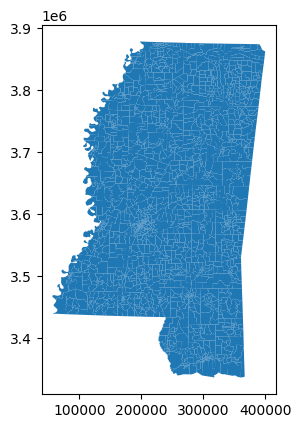

In [61]:
shapefile_path = "./{}/{}.shp".format(state_ab, state_ab)
shape=gpd.read_file(shapefile_path)
shape.plot()

In [62]:
list(election_df.columns)

['STATEFP18',
 'COUNTYFP18',
 'GEOID18',
 'NAME18',
 'VTDST18',
 'CD',
 'SEND',
 'HDIST',
 'TOTPOP',
 'NH_2MORE',
 'NH_AMIN',
 'NH_ASIAN',
 'NH_BLACK',
 'NH_NHPI',
 'NH_OTHER',
 'NH_WHITE',
 'HISP',
 'H_AMIN',
 'H_ASIAN',
 'H_BLACK',
 'H_NHPI',
 'H_OTHER',
 'H_WHITE',
 'H_2MORE',
 'VAP',
 'HVAP',
 'WVAP',
 'BVAP',
 'AMINVAP',
 'ASIANVAP',
 'NHPIVAP',
 'OTHERVAP',
 '2MOREVAP',
 'USS18D',
 'USS18O',
 'USS18R',
 'geometry']

In [63]:
len(election_df.columns)

37